plot_model_performance notebook
- Generates key visualizations to assess FALCON model performance,  namely hold-out test results and learning curves.
- Ensure the <u>Python 3.11 kernel (falcon-env)</u> is selected.
- Run configuration and functions before plotting
- Note: This script requires pre-trained models generated from run_FALCON.py.

In [36]:
### Required Run Parameters ### 

RUN_NAME = "09.02_Multivariable_analysis_v1_triplicate_averaged" #Name of folder from which to load the model
cell_type = "Transfection (%)" #Cell type of model to load 

### Configuration ###

In [37]:
#import statements 
import pickle 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from scipy import stats
import pandas as pd
from pathlib import Path


In [38]:
#load the model training pipeline results
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent
model_dir = PROJECT_ROOT / 'output' / RUN_NAME / cell_type
model_path = str(model_dir) + '/'
pipeline_path = model_dir / 'Pipeline_dict.pkl'

if not pipeline_path.exists():
    raise FileNotFoundError(f'Pipeline file was not found: {pipeline_path}')

with open(pipeline_path, 'rb') as file:
    pipeline_results = pickle.load(file)

loaded_data = pipeline_results['Data_preprocessing']['all_proc_data']
loaded_predictions = pipeline_results['Model_Selection']['Best_Model']['Predictions']
print(f'Loaded pipeline: {pipeline_path}')
print(f'Dataset path in pipeline: {pipeline_results["Data_preprocessing"]["Data_Path"]}')
print(f'Input params in pipeline: {pipeline_results["Data_preprocessing"]["Input_Params"]}')
print(f'Best model: {pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]}')
print(f'Training rows in pipeline: {len(loaded_data)}')
print(f'Final test prediction rows: {len(loaded_predictions)}')
if 'Fraction' in loaded_predictions.columns:
    print(f'Final test fractions: {sorted(loaded_predictions["Fraction"].dropna().astype(str).unique())}')
if 'Batch' in loaded_predictions.columns:
    print(f'Final test batches: {sorted(loaded_predictions["Batch"].dropna().astype(str).unique())}')


Loaded pipeline: /home/lucas/Documents/jupyter/falcon-universal-optimization/output/09.02_Multivariable_analysis_v1_triplicate_averaged/Transfection (%)/Pipeline_dict.pkl
Dataset path in pipeline: datasets/09.02_Multivariable_analysis_v1_triplicate_averaged.csv
Input params in pipeline: ['Formulation', 'Dose', 'Payload', 'Empty%', 'Size']
Best model: kNN
Training rows in pipeline: 60
Final test prediction rows: 12
Final test fractions: ['5']
Final test batches: ['1', '2']


### Functions ###

In [39]:
def format_axis_label(prefix, name, suffix=None):
    label = f'{prefix}\n{name}'
    if suffix is not None:
        label = f'{label} {suffix}'
    return label


def plot_predictions(pipeline, pred = None, exp = None, normalized = True, model_name = None, correlations = True):
    
    ######### Hold Out Validation Pred vs Exp. Plots ########

    if pred is None and exp is None:
        #Get Predictions
        model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
        data = pipeline['Model_Selection']['Best_Model']['Predictions']

        experimental = data['Experimental_Transfection']
        predicted = data['Predicted_Transfection']
    else:
        experimental = exp
        predicted = pred

    experimental = pd.Series(np.asarray(experimental).reshape(-1), dtype=float)
    predicted = pd.Series(np.asarray(predicted).reshape(-1), dtype=float)

    if not normalized:
        output_scaler = pipeline['Data_preprocessing'].get('Output_Scaler')
        if output_scaler is None:
            raise ValueError("Cannot plot non-normalized values because Output_Scaler is missing from the pipeline.")

        experimental = pd.Series(
            output_scaler.inverse_transform(experimental.to_numpy().reshape(-1, 1)).reshape(-1)
        )
        predicted = pd.Series(
            output_scaler.inverse_transform(predicted.to_numpy().reshape(-1, 1)).reshape(-1)
        )

    if normalized:
        lower_lim = -0.05
        upper_lim = 1.15
        ticks = np.linspace(0, 1, 5)
    else:
        all_values = np.concatenate([experimental.to_numpy(), predicted.to_numpy()])
        value_range = all_values.max() - all_values.min()
        padding = max(value_range * 0.08, 1)
        lower_lim = all_values.min() - padding
        upper_lim = all_values.max() + padding
        ticks = np.linspace(lower_lim, upper_lim, 5)

    #Config Plot
    # sns.set_theme(font='Arial', font_scale= 2)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 9

    #Plot
    fig = plt.figure(figsize=(2.5,2.5), dpi = 200)
    cmap = sns.color_palette("hls", 8, as_cmap=False)

    # color hex code used for ramos is #c8def9
    # color hex code used for thp1 is #FFC080

    reg = sns.regplot(x = experimental, 
                        y = predicted,
                        marker='.',
                        scatter_kws={"color": '#c8def9', "edgecolor": "black",
                                    "alpha": 0.8, "s":200}, 
                        line_kws={"color": "black", "linestyle":'--'})

    #Annotate with correlations
    if correlations:
        pearsons = stats.pearsonr(predicted, experimental)
        spearman = stats.spearmanr(predicted, experimental)

        plt.annotate("r = {:.2f}".format(pearsons[0]), xy=(0.1, 0.9), xycoords="axes fraction",fontsize = 10)
        plt.annotate("ρ = {:.2f}".format(spearman[0]), xy=(0.1, 0.8), xycoords="axes fraction",fontsize = 10)

    #Labels
    plt.ylabel(format_axis_label('Predicted', cell_type))
    plt.xlabel(format_axis_label('Experimental', cell_type))

    reg.set(xlim=(lower_lim, upper_lim), xticks=ticks, ylim=(lower_lim, upper_lim), yticks=ticks)
    reg.set_aspect('equal', adjustable='box')
    if not normalized:
        reg.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        reg.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        reg.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))
        reg.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))
    plt.xlim(lower_lim, upper_lim)
    plt.ylim(lower_lim, upper_lim)

    #Ticks
    reg.tick_params(colors='black', which='both')
    reg.tick_params(bottom=True, left=True)
    reg.axes.yaxis.label.set_color('black')
    reg.axes.xaxis.label.set_color('black')
    # reg.set_title("Hold-out Set Performance",weight="bold", fontsize = 15)

    # plt.tick_params(axis='both', which='major', labelsize=10)

    reg.spines['left'].set_color('black')
    reg.spines['bottom'].set_color('black')
    reg.spines['right'].set_visible(False)
    reg.spines['top'].set_visible(False)

    plt.grid(False)
    fig.tight_layout()
    
def plot_learning_curve(pipeline):
    #Extract Results
    cell = pipeline['Cell']
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']

    mean_train_scores = pipeline['Learning_Curve']['Train_Error']
    mean_validation_scores = pipeline['Learning_Curve']['Valid_Error']
    train_valid_scores = pd.concat([mean_validation_scores, mean_train_scores], 
                                   ignore_index= True)

    # Plot configurations
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 9})

    fig, ax = plt.subplots(figsize = (3.4, 1.7), dpi = 200)

    line = sns.lineplot(data =  train_valid_scores,
                            x = "Train_size", 
                            y = 'Percent_Error', 
                            hue = "Score_Type", 
                            errorbar = "sd", 
                            linewidth = 3, 
                            palette=sns.color_palette("Set2" , 2))

    #line.set(xlim=(0, 540), xticks=np.linspace(0,540,6), ylim=(0, 20), yticks=np.arange(0,25,5))
    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes
    
    # add tick marks on x-axis or y-axis
    line.tick_params(bottom=True, left=True)
    
    # x-axis and y-axis label color
    line.axes.yaxis.label.set_color('black')
    line.axes.xaxis.label.set_color('black')

    #line.set_yticklabels(line.get_yticklabels())
    #line.set_xticklabels(line.get_xticklabels())

    line.spines['left'].set_color('black')
    line.spines['bottom'].set_color('black')        # x-axis and y-axis spines
    line.spines['right'].set_visible(False)
    line.spines['top'].set_visible(False)

    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

    plt.grid(visible = False)
    plt.xlabel('Training size')
    plt.ylabel('Percent Error')
    plt.legend(fontsize = 'small', loc='upper left', bbox_to_anchor=(1.02, 1), framealpha = 0, borderaxespad=0)
    fig.subplots_adjust(right=0.72, bottom=0.22)


def get_prediction_frame(pipeline, normalized=True):
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
    data = pipeline['Model_Selection']['Best_Model']['Predictions'].copy()

    experimental = pd.Series(np.asarray(data['Experimental_Transfection']).reshape(-1), dtype=float)
    predicted = pd.Series(np.asarray(data['Predicted_Transfection']).reshape(-1), dtype=float)

    if not normalized:
        output_scaler = pipeline['Data_preprocessing'].get('Output_Scaler')
        if output_scaler is None:
            raise ValueError("Cannot plot non-normalized values because Output_Scaler is missing from the pipeline.")
        experimental = pd.Series(
            output_scaler.inverse_transform(experimental.to_numpy().reshape(-1, 1)).reshape(-1)
        )
        predicted = pd.Series(
            output_scaler.inverse_transform(predicted.to_numpy().reshape(-1, 1)).reshape(-1)
        )

    pred_frame = pd.DataFrame({
        'Formula label': data['Formula label'].to_numpy(),
        'Experimental': experimental,
        'Predicted': predicted,
        'Residual': experimental - predicted,
        'Model': model_name,
    })
    if 'Fraction' in data.columns:
        pred_frame['Fraction'] = data['Fraction'].to_numpy()
    if 'Batch' in data.columns:
        pred_frame['Batch'] = data['Batch'].to_numpy()
    return pred_frame


def plot_residuals_vs_predicted(pipeline, normalized=False):
    residuals = get_prediction_frame(pipeline, normalized=normalized)
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
    mae = np.mean(np.abs(residuals['Residual']))

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 9

    fig, ax = plt.subplots(figsize=(2.7, 2.3), dpi=200)
    sns.scatterplot(
        data=residuals,
        x='Predicted',
        y='Residual',
        marker='o',
        color='#c8def9',
        edgecolor='black',
        alpha=0.85,
        s=70,
        ax=ax,
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    ax.annotate(f'MAE = {mae:.1f}' if not normalized else f'MAE = {mae:.2f}',
                xy=(0.05, 0.9), xycoords='axes fraction', fontsize=9)
    ax.set_xlabel(format_axis_label('Predicted', cell_type))
    ax.set_ylabel(format_axis_label('Residual', cell_type))
    ax.set_title(f'{model_name} residuals', fontsize=9)

    if not normalized:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.subplots_adjust(left=0.24, bottom=0.24)
    return fig, ax, residuals


def plot_rank_correlation(pipeline, normalized=False):
    ranks = get_prediction_frame(pipeline, normalized=normalized)
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
    ranks['Experimental Rank'] = ranks['Experimental'].rank(method='average', ascending=False)
    ranks['Predicted Rank'] = ranks['Predicted'].rank(method='average', ascending=False)
    ranks['Rank Delta'] = ranks['Predicted Rank'] - ranks['Experimental Rank']

    spearman = stats.spearmanr(ranks['Experimental'], ranks['Predicted'])
    kendall = stats.kendalltau(ranks['Experimental'], ranks['Predicted'])

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 9

    fig, ax = plt.subplots(figsize=(2.7, 2.5), dpi=200)
    sns.scatterplot(
        data=ranks,
        x='Experimental Rank',
        y='Predicted Rank',
        marker='o',
        color='#c8def9',
        edgecolor='black',
        alpha=0.85,
        s=70,
        ax=ax,
    )

    max_rank = max(ranks['Experimental Rank'].max(), ranks['Predicted Rank'].max())
    ax.plot([1, max_rank], [1, max_rank], color='black', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.annotate(f'ρ = {spearman.statistic:.2f}', xy=(0.06, 0.90), xycoords='axes fraction', fontsize=9)
    ax.annotate(f'τ = {kendall.statistic:.2f}', xy=(0.06, 0.80), xycoords='axes fraction', fontsize=9)
    ax.set_xlabel(format_axis_label('Experimental', cell_type, 'rank'))
    ax.set_ylabel(format_axis_label('Predicted', cell_type, 'rank'))
    ax.set_title(f'{model_name} rank correlation', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.subplots_adjust(left=0.24, bottom=0.24)
    return fig, ax, ranks.sort_values('Experimental Rank').reset_index(drop=True)


def get_cv_performance_frame(pipeline):
    rows = []
    nested_cv = pipeline['Model_Selection'].get('NESTED_CV', {})
    for model_name, model_results in nested_cv.items():
        cv_df = model_results.get('HP_tuning_df')
        if cv_df is None:
            continue
        for _, row in cv_df.iterrows():
            rows.append({
                'Model': model_name,
                'Fold': int(row['Iter (CV Fold)']),
                'Score Type': 'Validation MAE',
                'MAE': float(row['Valid Score (MAE)']),
            })
            rows.append({
                'Model': model_name,
                'Fold': int(row['Iter (CV Fold)']),
                'Score Type': 'Outer Test MAE',
                'MAE': float(row['Test Score (MAE)']),
            })
    return pd.DataFrame(rows)


def select_representative_models(cv_perf, include_model='kNN', n_models=5):
    ranked_models = (
        cv_perf.groupby('Model')['MAE']
        .median()
        .sort_values()
        .index
        .tolist()
    )
    if len(ranked_models) <= n_models:
        return ranked_models

    positions = np.linspace(0, len(ranked_models) - 1, n_models).round().astype(int)
    selected = [ranked_models[pos] for pos in positions]

    if include_model in ranked_models and include_model not in selected:
        selected[-1] = include_model

    return [model for model in ranked_models if model in selected]


def plot_cv_performance_distribution(pipeline, representative_only=True, include_model='kNN', n_models=5):
    cv_perf = get_cv_performance_frame(pipeline)
    if cv_perf.empty:
        raise ValueError('No nested CV performance results found in the pipeline.')

    model_order = (
        cv_perf.groupby('Model')['MAE']
        .median()
        .sort_values()
        .index
        .tolist()
    )

    if representative_only:
        model_order = select_representative_models(cv_perf, include_model=include_model, n_models=n_models)
        cv_perf = cv_perf[cv_perf['Model'].isin(model_order)].copy()

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 9

    width = max(4.8, 0.85 * len(model_order))
    fig, ax = plt.subplots(figsize=(width, 2.8), dpi=200)

    sns.boxplot(
        data=cv_perf,
        x='Model',
        y='MAE',
        hue='Score Type',
        order=model_order,
        showfliers=False,
        width=0.65,
        linewidth=1,
        palette=sns.color_palette('Set2', 2),
        ax=ax,
    )
    sns.stripplot(
        data=cv_perf,
        x='Model',
        y='MAE',
        hue='Score Type',
        order=model_order,
        dodge=True,
        jitter=0.08,
        alpha=0.75,
        size=4,
        linewidth=0.4,
        edgecolor='black',
        palette=sns.color_palette('Set2', 2),
        ax=ax,
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        fontsize='small',
        framealpha=0,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )
    ax.set_xlabel('Model')
    ax.set_ylabel('MAE')
    ax.set_title('Nested CV fold performance', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.subplots_adjust(right=0.72, bottom=0.28)
    return fig, ax, cv_perf



### Plotting ###


########## MODEL SELECTION PLOTTING


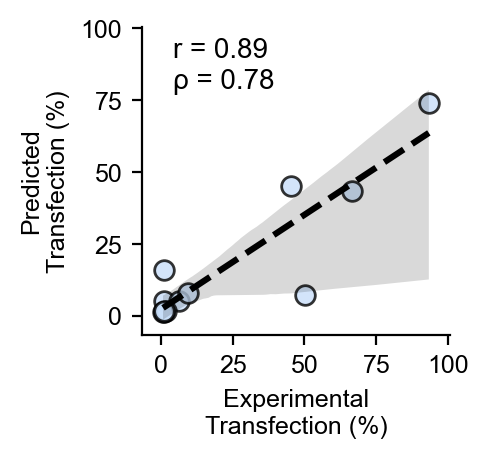

In [40]:
print()
print("########## MODEL SELECTION PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
plot_predictions(pipeline_results, normalized=False)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_predictions_raw.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")



########## LEARNING CURVE PLOTTING


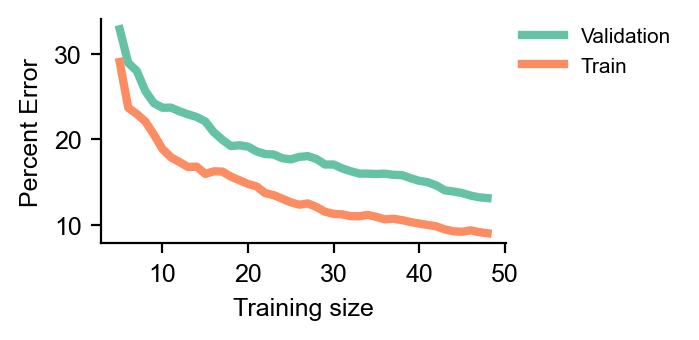

In [41]:
print()
print("########## LEARNING CURVE PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
plot_learning_curve(pipeline_results)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_learning_curve.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")



########## RESIDUALS VS PREDICTED PLOTTING


,Formula label,Experimental,Predicted,Residual,Model,Fraction,Batch
0,5,66.37,43.576,22.794,kNN,5,1
1,10,1.00,5.132,-4.132,kNN,5,2
2,15,6.38,5.132,1.248,kNN,5,2
3,20,45.33,45.194,0.136,kNN,5,1
4,25,1.21,15.820,-14.610,kNN,5,2
5,30,93.27,73.986,19.284,kNN,5,1
6,35,1.05,1.336,-0.286,kNN,5,1
7,40,1.89,1.712,0.178,kNN,5,2
8,45,0.78,1.290,-0.510,kNN,5,1
9,50,1.22,1.620,-0.400,kNN,5,2


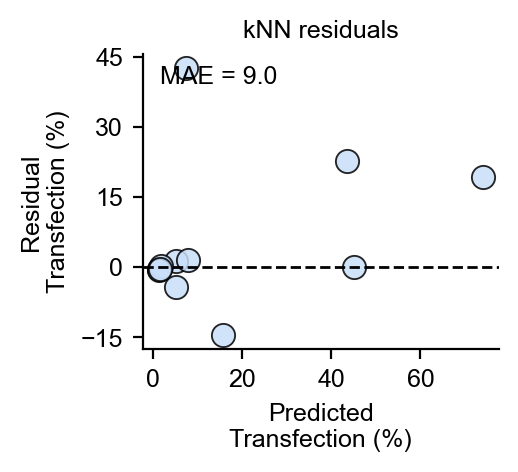

In [42]:
print()
print("########## RESIDUALS VS PREDICTED PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
residual_fig, residual_ax, residual_df = plot_residuals_vs_predicted(pipeline_results, normalized=False)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_residuals_vs_predicted_raw.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_residuals_vs_predicted_raw.png", dpi=300, transparent=True, bbox_inches = "tight")
residual_df



########## RANK CORRELATION PLOTTING


,Formula label,Experimental,Predicted,Residual,Model,Fraction,Batch,Experimental Rank,Predicted Rank,Rank Delta
0,30,93.27,73.986,19.284,kNN,5,1,1.0,1.0,0.0
1,5,66.37,43.576,22.794,kNN,5,1,2.0,3.0,1.0
2,55,50.13,7.406,42.724,kNN,5,1,3.0,6.0,3.0
3,20,45.33,45.194,0.136,kNN,5,1,4.0,2.0,-2.0
4,60,9.43,7.816,1.614,kNN,5,2,5.0,5.0,0.0
5,15,6.38,5.132,1.248,kNN,5,2,6.0,7.5,1.5
6,40,1.89,1.712,0.178,kNN,5,2,7.0,9.0,2.0
7,50,1.22,1.620,-0.400,kNN,5,2,8.0,10.0,2.0
8,25,1.21,15.820,-14.610,kNN,5,2,9.0,4.0,-5.0
9,35,1.05,1.336,-0.286,kNN,5,1,10.0,11.0,1.0


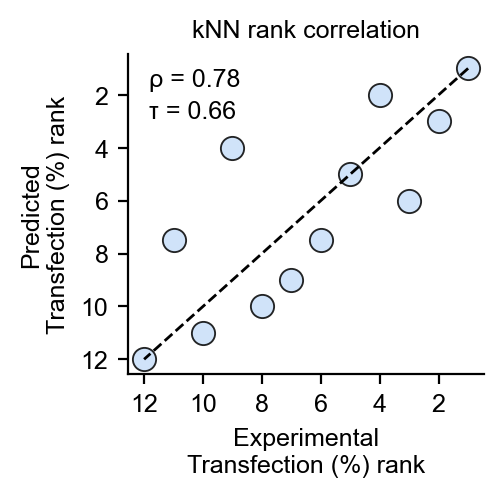

In [43]:
print()
print("########## RANK CORRELATION PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
rank_fig, rank_ax, rank_df = plot_rank_correlation(pipeline_results, normalized=False)

plt.savefig(model_path + f"{selected_model_name}_{cell_type}_rank_correlation_raw.svg", dpi=600, format = "svg", transparent=True, bbox_inches = "tight")
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_rank_correlation_raw.png", dpi=300, transparent=True, bbox_inches = "tight")
rank_df



########## CROSS VALIDATION PERFORMANCE DISTRIBUTION


,Model,Fold,Score Type,MAE
0,kNN,1,Validation MAE,0.181534
1,kNN,1,Outer Test MAE,0.128057
2,kNN,4,Validation MAE,0.114931
3,kNN,4,Outer Test MAE,0.184574
4,kNN,3,Validation MAE,0.149036
5,kNN,3,Outer Test MAE,0.073850
6,kNN,2,Validation MAE,0.127412
7,kNN,2,Outer Test MAE,0.228143
16,lasso,3,Validation MAE,0.246032
17,lasso,3,Outer Test MAE,0.205830


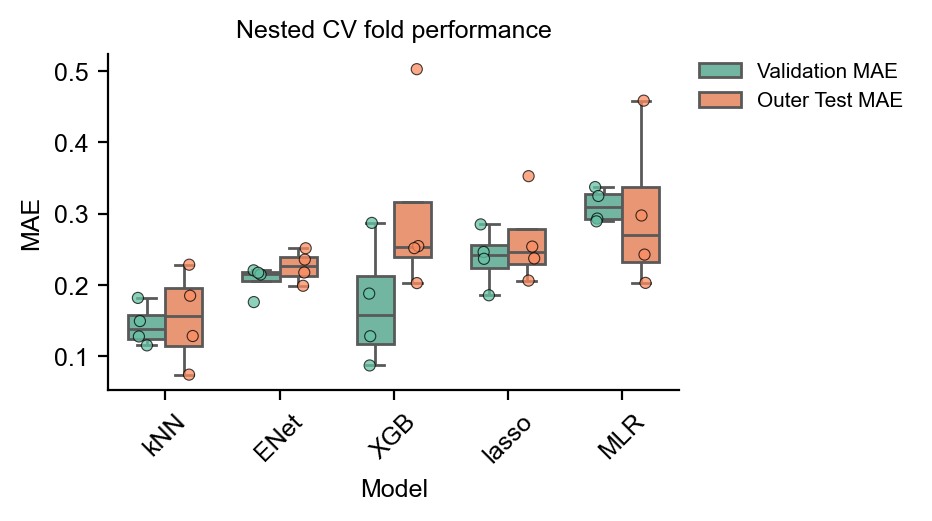

In [44]:
print()
print("########## CROSS VALIDATION PERFORMANCE DISTRIBUTION")
cv_fig, cv_ax, cv_performance_df = plot_cv_performance_distribution(pipeline_results, representative_only=True, include_model="kNN", n_models=5)

#example save statement
plt.savefig(model_path + f"{cell_type}_cv_fold_performance_distribution.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")
plt.savefig(model_path + f"{cell_type}_cv_fold_performance_distribution.png", dpi=300, transparent=True, bbox_inches = "tight")
cv_performance_df
